# Phase 3: Biologically Inspired Hidden Perturbations

Models are trained from scratch under each perturbation applied to the **1st hidden layer output**.  
Two model variants are compared:
- **SGD-delay** (solid, filled circles): SNN with learnable axonal delays.
- **SGD** (dashed, × markers): baseline SNN without delays.

Three dataset variants: **Whole** (blue), **Part** (green), **Norm** (red).

## 3A: Per-Spike Jitter

Independent Gaussian noise (σ ms) added to each spike time in the hidden layer output.  
Sweep: σ = 0 → 25 ms.

In [1]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

LOG_DIR = pathlib.Path("jitter/log")

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}


def load_sweep(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (sigma_values, means_pct, stds_pct) from a sweep results JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    sigmas = sorted(int(k) for k in raw)
    means = np.array([raw[str(s)]["mean"] for s in sigmas]) * 100
    stds = np.array([raw[str(s)]["std"] for s in sigmas]) * 100
    return sigmas, means, stds

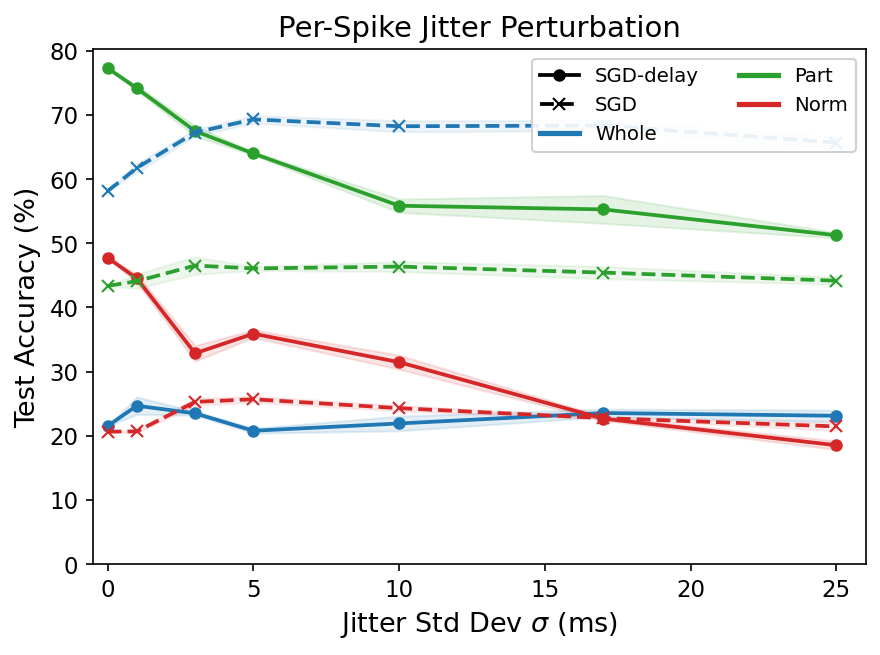

In [2]:
# ---------- Load sweep results ----------
whole_del_s, whole_del_m, whole_del_std = load_sweep(LOG_DIR / "jitter_whole_delay_jitter_sweep_results.json")
whole_nod_s, whole_nod_m, whole_nod_std = load_sweep(LOG_DIR / "jitter_whole_nodelay_jitter_sweep_results.json")
part_del_s,  part_del_m,  part_del_std  = load_sweep(LOG_DIR / "jitter_part_delay_jitter_sweep_results.json")
part_nod_s,  part_nod_m,  part_nod_std  = load_sweep(LOG_DIR / "jitter_part_nodelay_jitter_sweep_results.json")
norm_del_s,  norm_del_m,  norm_del_std  = load_sweep(LOG_DIR / "jitter_norm_delay_jitter_sweep_results.json")
norm_nod_s,  norm_nod_m,  norm_nod_std  = load_sweep(LOG_DIR / "jitter_norm_nodelay_jitter_sweep_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for s, m, std, key in [
    (whole_del_s, whole_del_m, whole_del_std, "Whole"),
    (part_del_s,  part_del_m,  part_del_std,  "Part"),
    (norm_del_s,  norm_del_m,  norm_del_std,  "Norm"),
]:
    ax.plot(s, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, × markers)
for s, m, std, key in [
    (whole_nod_s, whole_nod_m, whole_nod_std, "Whole"),
    (part_nod_s,  part_nod_m,  part_nod_std,  "Part"),
    (norm_nod_s,  norm_nod_m,  norm_nod_std,  "Norm"),
]:
    ax.plot(s, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Per-Spike Jitter Perturbation")
ax.set_xlabel(r"Jitter Std Dev $\sigma$ (ms)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.5, 26)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("jitter_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3B: Per-Neuron Shift

The same Gaussian offset is applied to **all spikes from a given hidden neuron**, preserving intra-neuron ISI while disrupting cross-neuron timing.  
Sweep: σ = 0 → 25 ms.

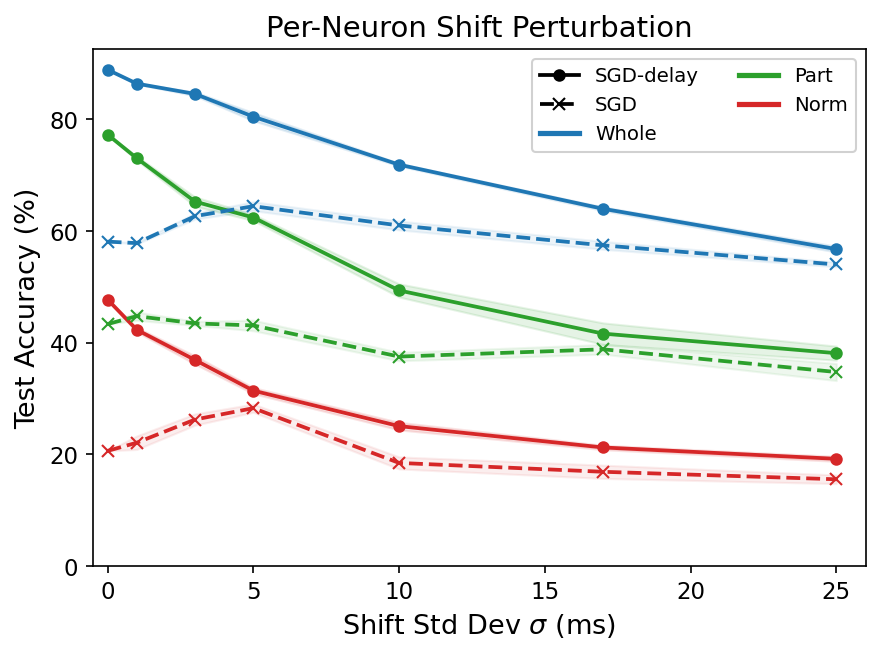

In [3]:
SHIFT_LOG = pathlib.Path("shift/log")

# ---------- Load sweep results ----------
s_whole_del_s, s_whole_del_m, s_whole_del_std = load_sweep(SHIFT_LOG / "shift_whole_delay_shift_sweep_results.json")
s_whole_nod_s, s_whole_nod_m, s_whole_nod_std = load_sweep(SHIFT_LOG / "shift_whole_nodelay_shift_sweep_results.json")
s_part_del_s,  s_part_del_m,  s_part_del_std  = load_sweep(SHIFT_LOG / "shift_part_delay_shift_sweep_results.json")
s_part_nod_s,  s_part_nod_m,  s_part_nod_std  = load_sweep(SHIFT_LOG / "shift_part_nodelay_shift_sweep_results.json")
s_norm_del_s,  s_norm_del_m,  s_norm_del_std  = load_sweep(SHIFT_LOG / "shift_norm_delay_shift_sweep_results.json")
s_norm_nod_s,  s_norm_nod_m,  s_norm_nod_std  = load_sweep(SHIFT_LOG / "shift_norm_nodelay_shift_sweep_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for s, m, std, key in [
    (s_whole_del_s, s_whole_del_m, s_whole_del_std, "Whole"),
    (s_part_del_s,  s_part_del_m,  s_part_del_std,  "Part"),
    (s_norm_del_s,  s_norm_del_m,  s_norm_del_std,  "Norm"),
]:
    ax.plot(s, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, × markers)
for s, m, std, key in [
    (s_whole_nod_s, s_whole_nod_m, s_whole_nod_std, "Whole"),
    (s_part_nod_s,  s_part_nod_m,  s_part_nod_std,  "Part"),
    (s_norm_nod_s,  s_norm_nod_m,  s_norm_nod_std,  "Norm"),
]:
    ax.plot(s, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Per-Neuron Shift Perturbation")
ax.set_xlabel(r"Shift Std Dev $\sigma$ (ms)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.5, 26)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("shift_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3C: Hidden Spike Deletion

Each spike in the hidden layer output is independently dropped with probability $p_d$, reducing the total spike count while preserving the timing of surviving spikes.  
Sweep: $p_d$ = 0 → 0.8.

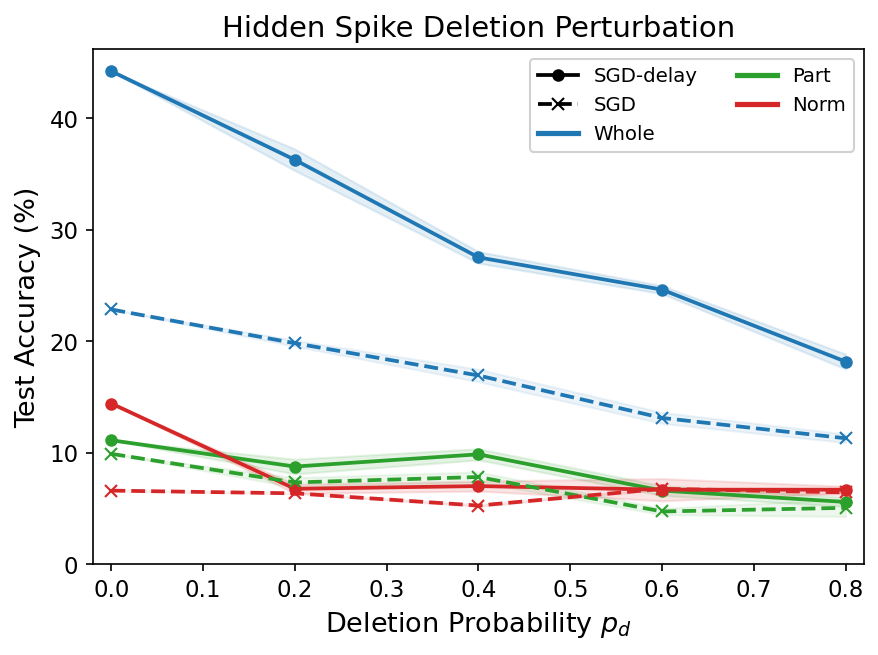

In [4]:
DELETION_LOG = pathlib.Path("deletion/log")


def load_sweep_pd(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (pd_values, means_pct, stds_pct) from a deletion sweep JSON.

    Deletion sweeps key their results by float deletion probability
    (e.g. "0.2"), so keys are parsed as float rather than int.
    """
    with open(path) as fh:
        raw = json.load(fh)
    pds = sorted(float(k) for k in raw)
    means = np.array([raw[str(p)]["mean"] for p in pds]) * 100
    stds = np.array([raw[str(p)]["std"] for p in pds]) * 100
    return pds, means, stds


# ---------- Load sweep results ----------
d_whole_del_p, d_whole_del_m, d_whole_del_std = load_sweep_pd(DELETION_LOG / "deletion_whole_delay_deletion_sweep_results.json")
d_whole_nod_p, d_whole_nod_m, d_whole_nod_std = load_sweep_pd(DELETION_LOG / "deletion_whole_nodelay_deletion_sweep_results.json")
d_part_del_p,  d_part_del_m,  d_part_del_std  = load_sweep_pd(DELETION_LOG / "deletion_part_delay_deletion_sweep_results.json")
d_part_nod_p,  d_part_nod_m,  d_part_nod_std  = load_sweep_pd(DELETION_LOG / "deletion_part_nodelay_deletion_sweep_results.json")
d_norm_del_p,  d_norm_del_m,  d_norm_del_std  = load_sweep_pd(DELETION_LOG / "deletion_norm_delay_deletion_sweep_results.json")
d_norm_nod_p,  d_norm_nod_m,  d_norm_nod_std  = load_sweep_pd(DELETION_LOG / "deletion_norm_nodelay_deletion_sweep_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for p, m, std, key in [
    (d_whole_del_p, d_whole_del_m, d_whole_del_std, "Whole"),
    (d_part_del_p,  d_part_del_m,  d_part_del_std,  "Part"),
    (d_norm_del_p,  d_norm_del_m,  d_norm_del_std,  "Norm"),
]:
    ax.plot(p, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(p, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, × markers)
for p, m, std, key in [
    (d_whole_nod_p, d_whole_nod_m, d_whole_nod_std, "Whole"),
    (d_part_nod_p,  d_part_nod_m,  d_part_nod_std,  "Part"),
    (d_norm_nod_p,  d_norm_nod_m,  d_norm_nod_std,  "Norm"),
]:
    ax.plot(p, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(p, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Hidden Spike Deletion Perturbation")
ax.set_xlabel(r"Deletion Probability $p_d$")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.02, 0.82)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("deletion_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()